# Лабораторная работа 3. Метод ближайших соседей и кросс-валидация

**Задание:**
1. Выбрать набор данных для задачи классификации.
2. Провести предобработку данных (пропуски, кодирование категориальных признаков).
3. Разделить выборку на обучающую и тестовую с помощью `train_test_split`.
4. Обучить модель ближайших соседей (KNN) для произвольного K, оценить качество.
5. Подобрать гиперпараметр K с помощью `GridSearchCV` и `RandomizedSearchCV` (две стратегии кросс-валидации).
6. Сравнить метрики исходной и оптимальной моделей.

## Подготовка: импорт библиотек

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import StratifiedKFold, ShuffleSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

import warnings
warnings.filterwarnings('ignore')

## 1. Выбор набора данных

Используем датасет **Students Performance in Exams** (`StudentsPerformance.csv`).

Датасет содержит информацию о результатах экзаменов студентов, а также демографические и социальные характеристики.

**Признаки:**
- `gender` — пол студента
- `race/ethnicity` — этническая группа
- `parental level of education` — уровень образования родителей
- `lunch` — тип обеда (standard / free/reduced)
- `test preparation course` — прохождение подготовительного курса (none / completed)
- `math score`, `reading score`, `writing score` — баллы по математике, чтению и письму

**Задача классификации:** предсказать, прошёл ли студент подготовительный курс (`test preparation course`) на основе остальных признаков.

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 2. Предобработка данных

### 2.1 Проверка пропусков

In [5]:
print('Количество пропусков по столбцам:')
print(df.isnull().sum())
print(f'\nОбщее количество пропусков: {df.isnull().sum().sum()}')

Количество пропусков по столбцам:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Общее количество пропусков: 0


Пропуски в данных отсутствуют, удаление или заполнение не требуется.

### 2.2 Формирование целевого признака и кодирование категориальных признаков

Распределение целевого признака (test preparation course):
test preparation course
none         642
completed    358
Name: count, dtype: int64


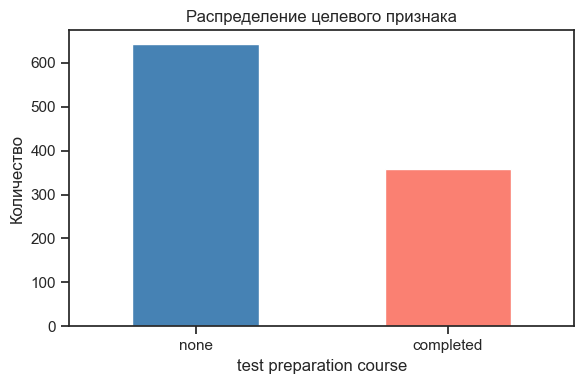

In [6]:
print('Распределение целевого признака (test preparation course):')
print(df['test preparation course'].value_counts())

plt.figure(figsize=(6, 4))
df['test preparation course'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Распределение целевого признака')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
y = LabelEncoder().fit_transform(df['test preparation course'])
print(f'Целевой признак (0 = completed, 1 = none): {np.unique(y, return_counts=True)}')

cat_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch']
num_columns = ['math score', 'reading score', 'writing score']

df_encoded = df.copy()
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df_encoded[cat_columns + num_columns].values
print(f'\nРазмерность матрицы признаков X: {X.shape}')
print(f'Размерность вектора целевого признака y: {y.shape}')

Целевой признак (0 = completed, 1 = none): (array([0, 1]), array([358, 642]))
gender: {'female': np.int64(0), 'male': np.int64(1)}
race/ethnicity: {'group A': np.int64(0), 'group B': np.int64(1), 'group C': np.int64(2), 'group D': np.int64(3), 'group E': np.int64(4)}
parental level of education: {"associate's degree": np.int64(0), "bachelor's degree": np.int64(1), 'high school': np.int64(2), "master's degree": np.int64(3), 'some college': np.int64(4), 'some high school': np.int64(5)}
lunch: {'free/reduced': np.int64(0), 'standard': np.int64(1)}

Размерность матрицы признаков X: (1000, 7)
Размерность вектора целевого признака y: (1000,)


### 2.3 Масштабирование признаков

Для метода KNN важно масштабировать признаки, так как алгоритм основан на расстояниях.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Средние значения признаков после масштабирования (≈0):')
print(np.round(X_scaled.mean(axis=0), 2))
print('\nСтандартные отклонения признаков после масштабирования (≈1):')
print(np.round(X_scaled.std(axis=0), 2))

Средние значения признаков после масштабирования (≈0):
[ 0.  0. -0. -0.  0.  0. -0.]

Стандартные отклонения признаков после масштабирования (≈1):
[1. 1. 1. 1. 1. 1. 1.]


## 3. Разделить выборку на обучающую и тестовую train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Размер обучающей выборки: {X_train.shape[0]}')
print(f'Размер тестовой выборки:  {X_test.shape[0]}')
print(f'\nРаспределение классов в обучающей выборке: {np.unique(y_train, return_counts=True)}')
print(f'Распределение классов в тестовой выборке:  {np.unique(y_test, return_counts=True)}')

Размер обучающей выборки: 700
Размер тестовой выборки:  300

Распределение классов в обучающей выборке: (array([0, 1]), array([251, 449]))
Распределение классов в тестовой выборке:  (array([0, 1]), array([107, 193]))


## 4. Обучить KNN для произвольного K и оценить качество

Выберем произвольное значение гиперпараметра K = 7.

In [10]:
K_INITIAL = 7

knn_initial = KNeighborsClassifier(n_neighbors=K_INITIAL)
knn_initial.fit(X_train, y_train)

y_train_pred = knn_initial.predict(X_train)
y_test_pred = knn_initial.predict(X_test)

### 4.1 Оценка качества исходной модели

In [11]:
print(f'=== Модель KNN с K={K_INITIAL} ===')
print(f'\nAccuracy (обучающая): {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Accuracy (тестовая):  {accuracy_score(y_test, y_test_pred):.4f}')
print(f'\nBalanced Accuracy (тестовая): {balanced_accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision (тестовая): {precision_score(y_test, y_test_pred):.4f}')
print(f'Recall (тестовая):    {recall_score(y_test, y_test_pred):.4f}')
print(f'F1-score (тестовая):  {f1_score(y_test, y_test_pred):.4f}')

=== Модель KNN с K=7 ===

Accuracy (обучающая): 0.7129
Accuracy (тестовая):  0.6200

Balanced Accuracy (тестовая): 0.5443
Precision (тестовая): 0.6695
Recall (тестовая):    0.8083
F1-score (тестовая):  0.7324


In [12]:
print('Отчёт по классификации (тестовая выборка):')
print(classification_report(y_test, y_test_pred, target_names=['completed', 'none']))

Отчёт по классификации (тестовая выборка):
              precision    recall  f1-score   support

   completed       0.45      0.28      0.34       107
        none       0.67      0.81      0.73       193

    accuracy                           0.62       300
   macro avg       0.56      0.54      0.54       300
weighted avg       0.59      0.62      0.59       300



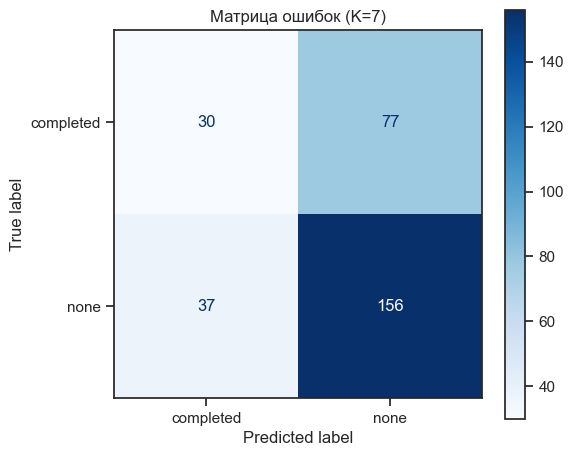

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['completed', 'none'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Матрица ошибок (K={K_INITIAL})')
plt.tight_layout()
plt.show()

### 4.2 ROC-кривая исходной модели

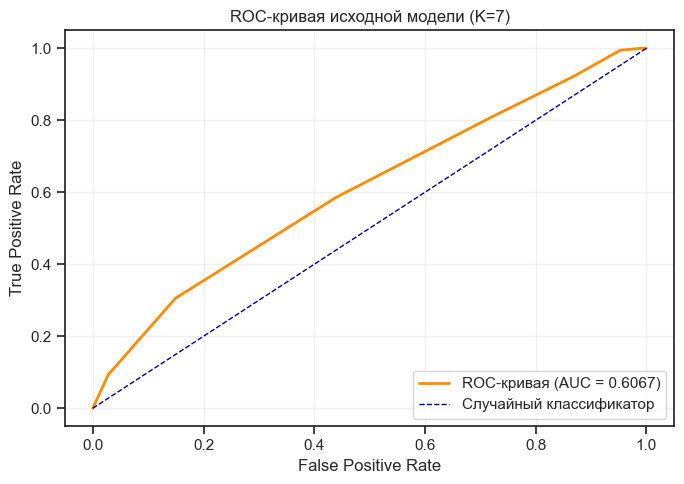

In [14]:
y_test_proba = knn_initial.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc_initial = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc_initial:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая исходной модели (K={K_INITIAL})')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.0 Подготовка метрик для кросс-валидации

In [15]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

cv_scores = cross_validate(
    KNeighborsClassifier(n_neighbors=K_INITIAL),
    X_scaled, y,
    scoring=scoring,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    return_train_score=True
)

print(f'Пункт 5: кросс-валидация KNN с K={K_INITIAL} (StratifiedKFold, 5 фолдов):')
print(f'\nAccuracy по фолдам:  {cv_scores["test_accuracy"]}')
print(f'Средний Accuracy:    {cv_scores["test_accuracy"].mean():.4f} ± {cv_scores["test_accuracy"].std():.4f}')
print(f'\nF1 по фолдам:        {cv_scores["test_f1"]}')
print(f'Средний F1:          {cv_scores["test_f1"].mean():.4f} ± {cv_scores["test_f1"].std():.4f}')

Пункт 5: кросс-валидация KNN с K=7 (StratifiedKFold, 5 фолдов):

Accuracy по фолдам:  [0.64  0.585 0.62  0.585 0.595]
Средний Accuracy:    0.6050 ± 0.0217

F1 по фолдам:        [0.74825175 0.6959707  0.7414966  0.70462633 0.70967742]
Средний F1:          0.7200 ± 0.0209


## 5. Подбор гиперпараметра K с помощью GridSearchCV и RandomizedSearchCV

### 5.1 GridSearchCV со стратегией StratifiedKFold

Стратегия **StratifiedKFold** сохраняет баланс классов целевого признака в каждом фолде, что важно при несбалансированных данных.

In [16]:
k_range = np.arange(1, 51, 2)
param_grid = {'n_neighbors': k_range}
print(f'Диапазон K для поиска: {k_range}')

Диапазон K для поиска: [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47
 49]


In [17]:
%%time

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_gs = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv_stratified,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
clf_gs.fit(X_scaled, y)

CPU times: user 89.3 ms, sys: 87.6 ms, total: 177 ms
Wall time: 1.37 s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39, 41, 43, 45, 47, 49])},
             return_train_score=True, scoring='accuracy')

In [18]:
print('Пункт 5.1: GridSearchCV (стратегия: StratifiedKFold, 5 фолдов)')
print(f'Лучшее значение K:        {clf_gs.best_params_["n_neighbors"]}')
print(f'Лучшее значение Accuracy:  {clf_gs.best_score_:.4f}')
print(f'Лучшая модель:             {clf_gs.best_estimator_}')

Пункт 5.1: GridSearchCV (стратегия: StratifiedKFold, 5 фолдов)
Лучшее значение K:        11
Лучшее значение Accuracy:  0.6540
Лучшая модель:             KNeighborsClassifier(n_neighbors=np.int64(11))


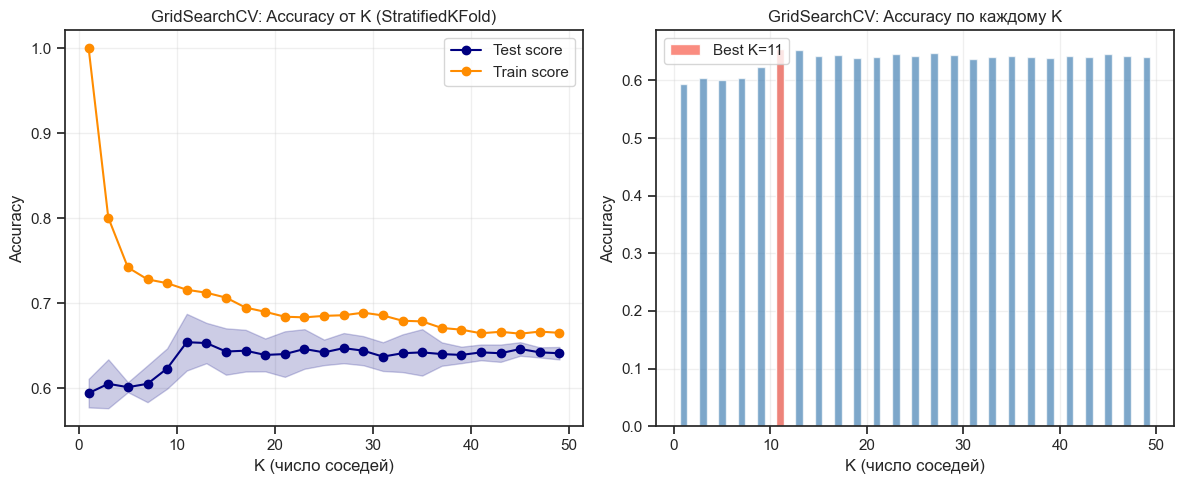

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, clf_gs.cv_results_['mean_test_score'], 'o-', color='navy', label='Test score')
plt.plot(k_range, clf_gs.cv_results_['mean_train_score'], 'o-', color='darkorange', label='Train score')
plt.fill_between(k_range,
                 clf_gs.cv_results_['mean_test_score'] - clf_gs.cv_results_['std_test_score'],
                 clf_gs.cv_results_['mean_test_score'] + clf_gs.cv_results_['std_test_score'],
                 alpha=0.2, color='navy')
plt.xlabel('K (число соседей)')
plt.ylabel('Accuracy')
plt.title('GridSearchCV: Accuracy от K (StratifiedKFold)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
best_k_gs = clf_gs.best_params_['n_neighbors']
plt.bar(k_range, clf_gs.cv_results_['mean_test_score'], color='steelblue', alpha=0.7)
plt.bar(best_k_gs, clf_gs.best_score_, color='salmon', alpha=0.9, label=f'Best K={best_k_gs}')
plt.xlabel('K (число соседей)')
plt.ylabel('Accuracy')
plt.title('GridSearchCV: Accuracy по каждому K')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 RandomizedSearchCV со стратегией ShuffleSplit

Стратегия **ShuffleSplit** формирует случайные разбиения train/test заданное число раз. Это удобно для быстрой устойчивой оценки без жёсткой привязки к фолдам.

In [20]:
%%time

param_dist = {'n_neighbors': np.arange(1, 51)}

cv_shuffle = ShuffleSplit(n_splits=15, test_size=0.2, random_state=42)

clf_rs = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist,
    n_iter=25,
    cv=cv_shuffle,
    scoring='accuracy',
    random_state=42,
    return_train_score=True,
    n_jobs=-1
)
clf_rs.fit(X_scaled, y)

CPU times: user 109 ms, sys: 16.1 ms, total: 125 ms
Wall time: 670 ms


RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=5, random_state=42),
                   estimator=KNeighborsClassifier(), n_iter=25, n_jobs=-1,
                   param_distributions={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [21]:
print('Пункт 5.2: RandomizedSearchCV (стратегия: ShuffleSplit, 15 случайных разбиений)')
print(f'Количество итераций:       {clf_rs.n_splits_}')
print(f'Лучшее значение K:         {clf_rs.best_params_["n_neighbors"]}')
print(f'Лучшее значение Accuracy:  {clf_rs.best_score_:.4f}')
print(f'Лучшая модель:             {clf_rs.best_estimator_}')

Пункт 5.2: RandomizedSearchCV (стратегия: RepeatedStratifiedKFold, 5 фолдов × 3 повторения)
Количество итераций:       15
Лучшее значение K:         27
Лучшее значение Accuracy:  0.6547
Лучшая модель:             KNeighborsClassifier(n_neighbors=np.int64(27))


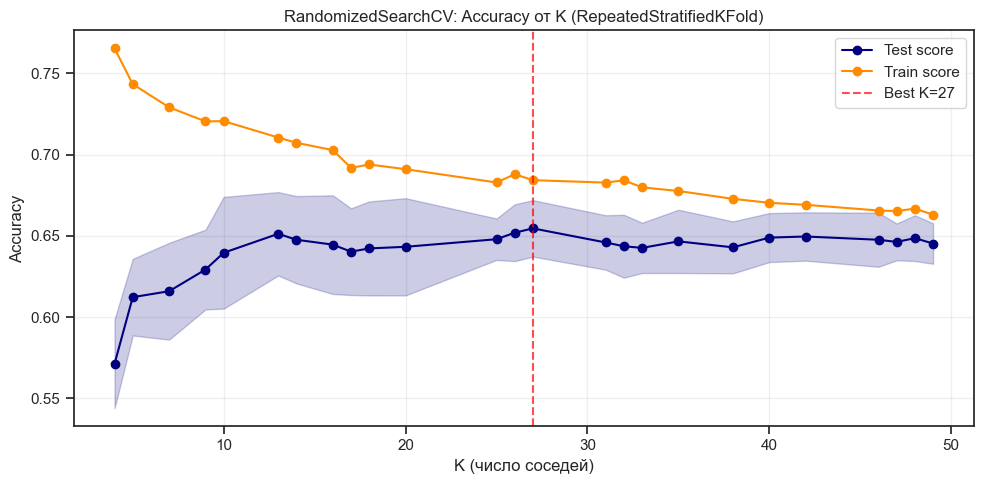

In [22]:
results_rs = pd.DataFrame(clf_rs.cv_results_)
results_rs = results_rs.sort_values('param_n_neighbors')

plt.figure(figsize=(10, 5))
plt.plot(results_rs['param_n_neighbors'], results_rs['mean_test_score'],
         'o-', color='navy', label='Test score')
plt.plot(results_rs['param_n_neighbors'], results_rs['mean_train_score'],
         'o-', color='darkorange', label='Train score')
plt.fill_between(results_rs['param_n_neighbors'].astype(int),
                 results_rs['mean_test_score'] - results_rs['std_test_score'],
                 results_rs['mean_test_score'] + results_rs['std_test_score'],
                 alpha=0.2, color='navy')

best_k_rs = clf_rs.best_params_['n_neighbors']
plt.axvline(x=best_k_rs, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_rs}')
plt.xlabel('K (число соседей)')
plt.ylabel('Accuracy')
plt.title('RandomizedSearchCV: Accuracy от K (ShuffleSplit)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.1 Обучение и оценка оптимальной модели

In [23]:
best_k = clf_gs.best_params_['n_neighbors']
print(f'Оптимальное K (GridSearchCV):        {clf_gs.best_params_["n_neighbors"]}')
print(f'Оптимальное K (RandomizedSearchCV):  {clf_rs.best_params_["n_neighbors"]}')
print(f'\nИспользуем K = {best_k} (из GridSearchCV)')

Оптимальное K (GridSearchCV):        11
Оптимальное K (RandomizedSearchCV):  27

Используем K = 11 (из GridSearchCV)


In [24]:
knn_optimal = clf_gs.best_estimator_
knn_optimal.fit(X_train, y_train)

y_train_pred_opt = knn_optimal.predict(X_train)
y_test_pred_opt = knn_optimal.predict(X_test)

In [25]:
print(f'=== Оптимальная модель KNN с K={best_k} ===')
print(f'\nAccuracy (обучающая): {accuracy_score(y_train, y_train_pred_opt):.4f}')
print(f'Accuracy (тестовая):  {accuracy_score(y_test, y_test_pred_opt):.4f}')
print(f'\nBalanced Accuracy (тестовая): {balanced_accuracy_score(y_test, y_test_pred_opt):.4f}')
print(f'Precision (тестовая): {precision_score(y_test, y_test_pred_opt):.4f}')
print(f'Recall (тестовая):    {recall_score(y_test, y_test_pred_opt):.4f}')
print(f'F1-score (тестовая):  {f1_score(y_test, y_test_pred_opt):.4f}')

=== Оптимальная модель KNN с K=11 ===

Accuracy (обучающая): 0.7129
Accuracy (тестовая):  0.6633

Balanced Accuracy (тестовая): 0.5822
Precision (тестовая): 0.6901
Recall (тестовая):    0.8653
F1-score (тестовая):  0.7678


In [26]:
print('Отчёт по классификации (тестовая выборка):')
print(classification_report(y_test, y_test_pred_opt, target_names=['completed', 'none']))

Отчёт по классификации (тестовая выборка):
              precision    recall  f1-score   support

   completed       0.55      0.30      0.39       107
        none       0.69      0.87      0.77       193

    accuracy                           0.66       300
   macro avg       0.62      0.58      0.58       300
weighted avg       0.64      0.66      0.63       300



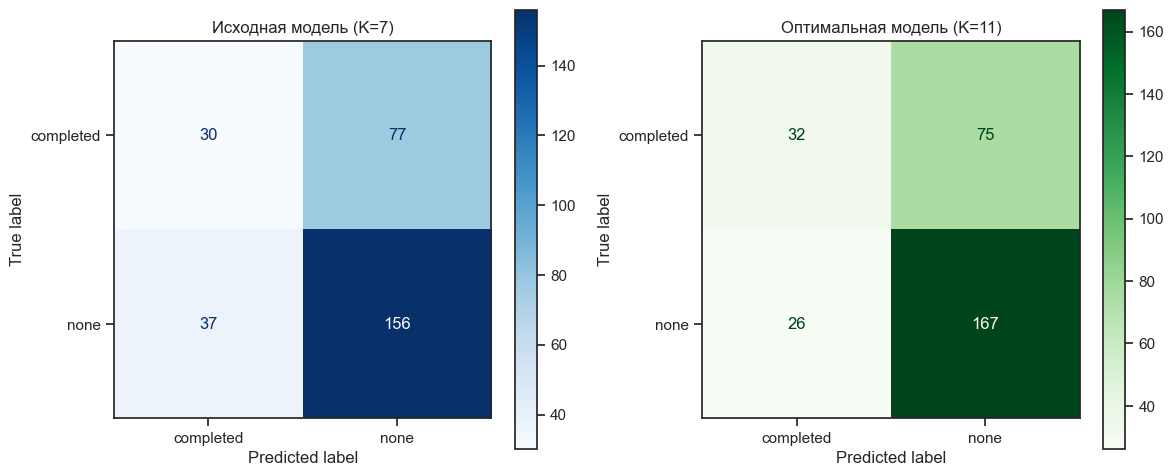

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_initial = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_initial, display_labels=['completed', 'none']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Исходная модель (K={K_INITIAL})')

cm_optimal = confusion_matrix(y_test, y_test_pred_opt)
ConfusionMatrixDisplay(cm_optimal, display_labels=['completed', 'none']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Оптимальная модель (K={best_k})')

plt.tight_layout()
plt.show()

## 6. Сравнить метрики исходной и оптимальной моделей

In [28]:
y_test_proba_opt = knn_optimal.predict_proba(X_test)[:, 1]
roc_auc_optimal = roc_auc_score(y_test, y_test_proba_opt)

comparison = pd.DataFrame({
    'Метрика': ['Accuracy (train)', 'Accuracy (test)', 'Balanced Accuracy',
                'Precision', 'Recall', 'F1-score', 'ROC AUC'],
    f'Исходная (K={K_INITIAL})': [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
        balanced_accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_initial
    ],
    f'Оптимальная (K={best_k})': [
        accuracy_score(y_train, y_train_pred_opt),
        accuracy_score(y_test, y_test_pred_opt),
        balanced_accuracy_score(y_test, y_test_pred_opt),
        precision_score(y_test, y_test_pred_opt),
        recall_score(y_test, y_test_pred_opt),
        f1_score(y_test, y_test_pred_opt),
        roc_auc_optimal
    ]
})

comparison['Разница'] = comparison[f'Оптимальная (K={best_k})'] - comparison[f'Исходная (K={K_INITIAL})']
comparison = comparison.round(4)
comparison

,Метрика,Исходная (K=7),Оптимальная (K=11),Разница
0,Accuracy (train),0.7129,0.7129,0.0000
1,Accuracy (test),0.6200,0.6633,0.0433
2,Balanced Accuracy,0.5443,0.5822,0.0378
3,Precision,0.6695,0.6901,0.0206
4,Recall,0.8083,0.8653,0.0570
5,F1-score,0.7324,0.7678,0.0354
6,ROC AUC,0.6067,0.6470,0.0404


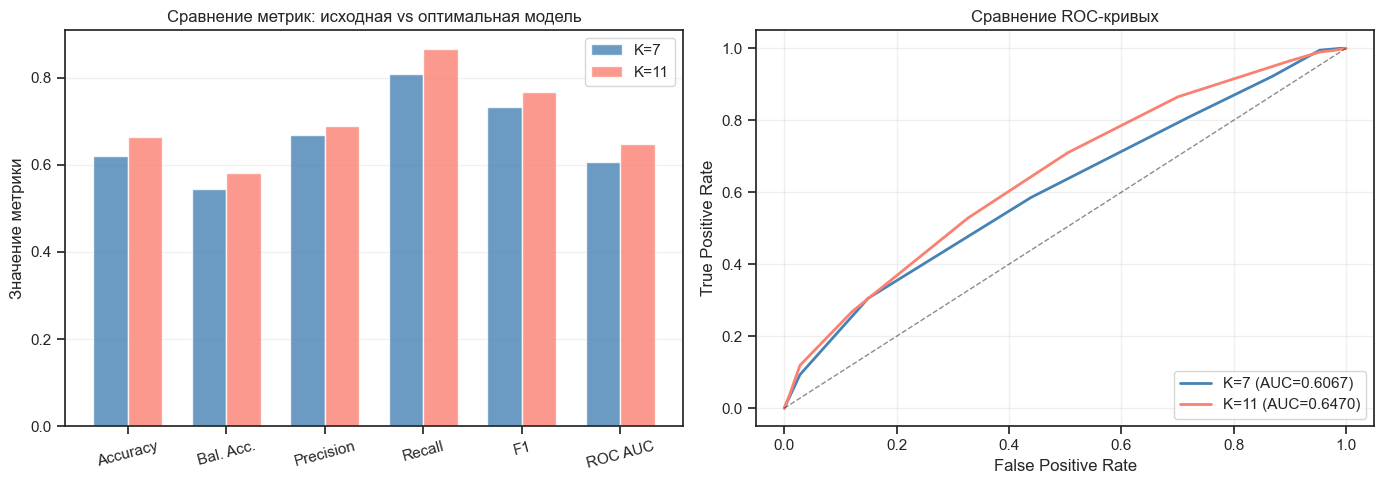

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names = ['Accuracy', 'Bal. Acc.', 'Precision', 'Recall', 'F1', 'ROC AUC']
initial_vals = comparison.iloc[1:][f'Исходная (K={K_INITIAL})'].values
optimal_vals = comparison.iloc[1:][f'Оптимальная (K={best_k})'].values

x = np.arange(len(metrics_names))
width = 0.35

axes[0].bar(x - width/2, initial_vals, width, label=f'K={K_INITIAL}', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, optimal_vals, width, label=f'K={best_k}', color='salmon', alpha=0.8)
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение метрик: исходная vs оптимальная модель')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

fpr_opt, tpr_opt, _ = roc_curve(y_test, y_test_proba_opt)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'K={K_INITIAL} (AUC={roc_auc_initial:.4f})')
axes[1].plot(fpr_opt, tpr_opt, color='salmon', lw=2, label=f'K={best_k} (AUC={roc_auc_optimal:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Сравнение ROC-кривых')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Дополнительные графики (опционально, вне задания).

In [30]:
def plot_learning_curve(estimator, title, X, y, cv=None,
                        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, train_sizes=train_sizes
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel(scoring)
    plt.grid(True, alpha=0.3)

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='r')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='g')
    plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

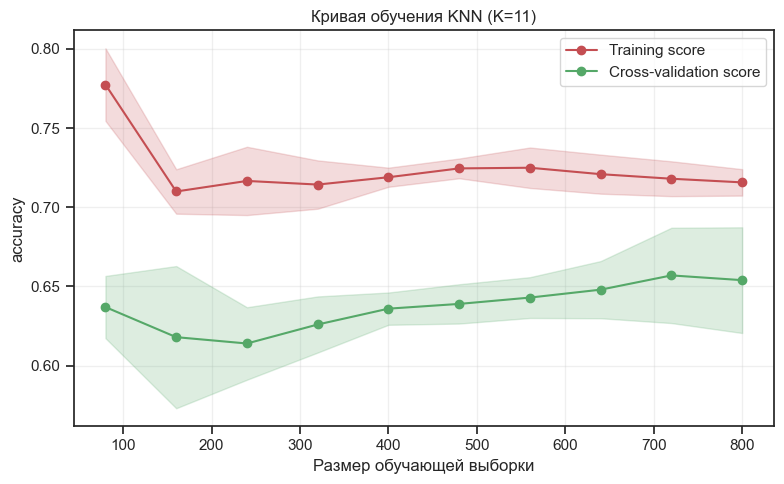

In [31]:
plot_learning_curve(
    knn_optimal,
    f'Кривая обучения KNN (K={best_k})',
    X_scaled, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

In [32]:
def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv, scoring='accuracy'):
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel(scoring)
    plt.grid(True, alpha=0.3)

    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color='darkorange')
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color='navy')
    plt.plot(param_range, train_mean, 'o-', color='darkorange', lw=2, label='Training score')
    plt.plot(param_range, test_mean, 'o-', color='navy', lw=2, label='Cross-validation score')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

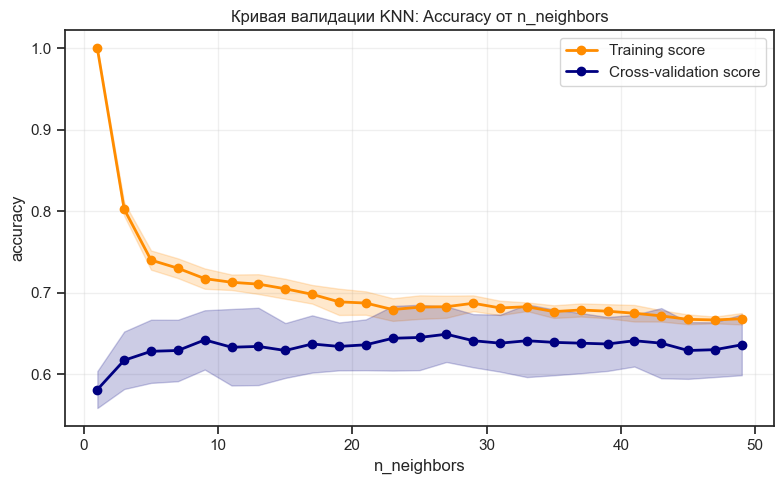

In [33]:
plot_validation_curve(
    KNeighborsClassifier(),
    'Кривая валидации KNN: Accuracy от n_neighbors',
    X_scaled, y,
    param_name='n_neighbors',
    param_range=np.arange(1, 51, 2),
    cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
)